#Cervical Cancer Prediction - Full ML pipeline

##1. Mount Drive & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/cervical-cancer-ml/{data,models}

Mounted at /content/drive


##2. Install & Import Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost lightgbm shap joblib -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap

warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, average_precision_score,
    precision_recall_curve
)

print('All libraries imported successfully!')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')

All libraries imported successfully!
NumPy: 2.0.2, Pandas: 2.2.2


##3. Load & Explore DataSet

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/cervical-cancer-ml/data/risk_factors_cervical_cancer.csv")
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (858, 36)
Columns: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


##4. Data Preprocessing

In [ ]:
# Step 1: Replace '?' with NaN — critical first step
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.astype(float)

# Step 2: Show missing value counts
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Columns with missing values:')
print(missing_df[missing_df['Missing Count'] > 0])

Columns with missing values:
                                    Missing Count  Missing %
STDs: Time since first diagnosis              787       91.7
STDs: Time since last diagnosis               787       91.7
IUD                                           117       13.6
IUD (years)                                   117       13.6
Hormonal Contraceptives                       108       12.6
Hormonal Contraceptives (years)               108       12.6
STDs:HPV                                      105       12.2
STDs:AIDS                                     105       12.2
STDs:Hepatitis B                              105       12.2
STDs:HIV                                      105       12.2
STDs                                          105       12.2
STDs:cervical condylomatosis                  105       12.2
STDs:vulvo-perineal condylomatosis            105       12.2
STDs:syphilis                                 105       12.2
STDs:pelvic inflammatory disease              105       

In [ ]:
# Step 3: Drop columns with >40% missing data
cols_to_drop = ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f'Shape after dropping high-missing columns: {df.shape}')

# Step 4: Median imputation for remaining missing values
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)
print(f'Remaining nulls: {df_imputed.isnull().sum().sum()}')

Shape after dropping high-missing columns: (858, 34)
Remaining nulls: 0


Class distribution:
Biopsy
0.0    803
1.0     55
Name: count, dtype: int64
Imbalance ratio (neg/pos): 14.6:1


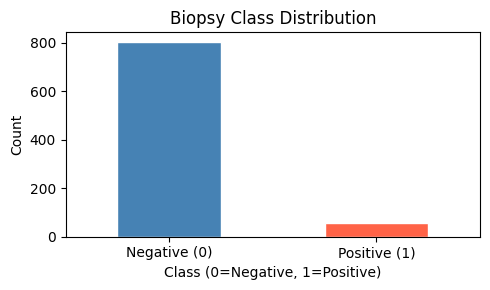

In [ ]:
# Step 5: Target variable — Biopsy (most clinically relevant)
X = df_imputed.drop(columns=['Biopsy'])
y = df_imputed['Biopsy']

print('Class distribution:')
print(y.value_counts())
print(f'Imbalance ratio (neg/pos): {y.value_counts()[0.0] / y.value_counts()[1.0]:.1f}:1')

# Visualise class imbalance
fig, ax = plt.subplots(figsize=(5, 3))
y.value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Biopsy Class Distribution')
ax.set_xlabel('Class (0=Negative, 1=Positive)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
plt.tight_layout()
plt.show()

##5. Train/Test Split & Scaling

In [ ]:
# Stratified split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate:  {y_test.mean():.3f}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Apply SMOTE only on training set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE — Train size: {X_train_smote.shape[0]}')
print(f'After SMOTE — Class counts: {pd.Series(y_train_smote).value_counts().to_dict()}')

# Save scaler
joblib.dump(scaler, "/content/drive/MyDrive/cervical-cancer-ml/models/scaler.pkl")

Train size: 686, Test size: 172
Train positive rate: 0.064
Test positive rate:  0.064
After SMOTE — Train size: 1284
After SMOTE — Class counts: {0.0: 642, 1.0: 642}


['/content/drive/MyDrive/cervical-cancer-ml/models/scaler.pkl']

##Define & Train all Models
Models covered:

- **Classical:** Logistic Regression, SVM, KNN, Naive Bayes
- **Tree-Based:** Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightBGM
- **Neural Network:** MLP
- **Ensemble:** Voting Classifier, Stacking Classifier

In [ ]:
# Compute class weight scale for XGBoost/LightGBM
scale_pos_weight = float(y_train.value_counts()[0.0]) / float(y_train.value_counts()[1.0])
print(f'scale_pos_weight for XGB/LGBM: {scale_pos_weight:.2f}')

# ── Define all models ──────────────────────────────────────────────────────────
models = {
    # Classical
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'SVM': SVC(
        probability=True, class_weight='balanced', random_state=42
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),

    # Tree-based
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42, max_depth=5
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=42, verbosity=-1
    ),

    # Neural Network
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        max_iter=500, random_state=42
    ),
}

print(f'Total models to train: {len(models)}')

scale_pos_weight for XGB/LGBM: 14.59
Total models to train: 10


In [ ]:
# ── Train all models & collect predictions ────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'pr_auc':    average_precision_score(y_test, y_proba),
    }
    print(f'{name:25s}  AUC={results[name]["roc_auc"]:.4f}  F1={results[name]["f1"]:.4f}  Recall={results[name]["recall"]:.4f}')

print('\nAll models trained!')

Logistic Regression        AUC=0.8905  F1=0.7200  Recall=0.8182
SVM                        AUC=0.9051  F1=0.7500  Recall=0.8182
KNN                        AUC=0.8433  F1=0.5714  Recall=0.7273
Naive Bayes                AUC=0.5217  F1=0.1243  Recall=1.0000
Decision Tree              AUC=0.8549  F1=0.6667  Recall=0.7273
Random Forest              AUC=0.9678  F1=0.7000  Recall=0.6364
Gradient Boosting          AUC=0.9159  F1=0.6316  Recall=0.5455
XGBoost                    AUC=0.9509  F1=0.7273  Recall=0.7273
LightGBM                   AUC=0.9627  F1=0.7273  Recall=0.7273
MLP                        AUC=0.8413  F1=0.4211  Recall=0.3636

All models trained!


##7. Add Ensemble Models (Voting + Stacking)

In [ ]:
# ── Voting Classifier (top 3 by AUC) ──────────────────────────────────────────
# Re-train base models with their individual results already collected;
# sklearn VotingClassifier needs unfitted estimators at init but we re-fit here.

voting_clf = VotingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                               scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                               random_state=42, verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                scale_pos_weight=scale_pos_weight, random_state=42, verbosity=-1)),
    ],
    voting='soft'
)
voting_clf.fit(X_train_smote, y_train_smote)
y_pred_v  = voting_clf.predict(X_test_scaled)
y_proba_v = voting_clf.predict_proba(X_test_scaled)[:, 1]

results['Voting Ensemble'] = {
    'model':     voting_clf,
    'y_pred':    y_pred_v,
    'y_proba':   y_proba_v,
    'accuracy':  accuracy_score(y_test, y_pred_v),
    'precision': precision_score(y_test, y_pred_v, zero_division=0),
    'recall':    recall_score(y_test, y_pred_v, zero_division=0),
    'f1':        f1_score(y_test, y_pred_v, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, y_proba_v),
    'pr_auc':    average_precision_score(y_test, y_proba_v),
}

# ── Stacking Classifier ─────────────────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=100, learning_rate=0.05, scale_pos_weight=scale_pos_weight,
                               eval_metric='logloss', random_state=42, verbosity=0)),
        ('lgbm', LGBMClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, random_state=42, verbosity=-1)),
        ('lr',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train_smote, y_train_smote)
y_pred_s  = stacking_clf.predict(X_test_scaled)
y_proba_s = stacking_clf.predict_proba(X_test_scaled)[:, 1]

results['Stacking Ensemble'] = {
    'model':     stacking_clf,
    'y_pred':    y_pred_s,
    'y_proba':   y_proba_s,
    'accuracy':  accuracy_score(y_test, y_pred_s),
    'precision': precision_score(y_test, y_pred_s, zero_division=0),
    'recall':    recall_score(y_test, y_pred_s, zero_division=0),
    'f1':        f1_score(y_test, y_pred_s, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, y_proba_s),
    'pr_auc':    average_precision_score(y_test, y_proba_s),
}

for name in ['Voting Ensemble', 'Stacking Ensemble']:
    r = results[name]
    print(f'{name:25s}  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  Recall={r["recall"]:.4f}')

Voting Ensemble            AUC=0.9667  F1=0.7826  Recall=0.8182
Stacking Ensemble          AUC=0.9678  F1=0.7826  Recall=0.8182


##8. Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
        'F1 Score':  round(r['f1'],        4),
        'ROC-AUC':   round(r['roc_auc'],   4),
        'PR-AUC':    round(r['pr_auc'],    4),
    }
    for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print('Model Comparison (sorted by ROC-AUC):')
comparison_df

Model Comparison (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Stacking Ensemble,0.9709,0.7500,0.8182,0.7826,0.9678,0.7218
Random Forest,0.9651,0.7778,0.6364,0.7000,0.9678,0.7101
Voting Ensemble,0.9709,0.7500,0.8182,0.7826,0.9667,0.6989
LightGBM,0.9651,0.7273,0.7273,0.7273,0.9627,0.6734
XGBoost,0.9651,0.7273,0.7273,0.7273,0.9509,0.6549
Gradient Boosting,0.9593,0.7500,0.5455,0.6316,0.9159,0.6164
SVM,0.9651,0.6923,0.8182,0.7500,0.9051,0.6115
Logistic Regression,0.9593,0.6429,0.8182,0.7200,0.8905,0.5296
Decision Tree,0.9535,0.6154,0.7273,0.6667,0.8549,0.5993
KNN,0.9302,0.4706,0.7273,0.5714,0.8433,0.4850


##9. Visualisations

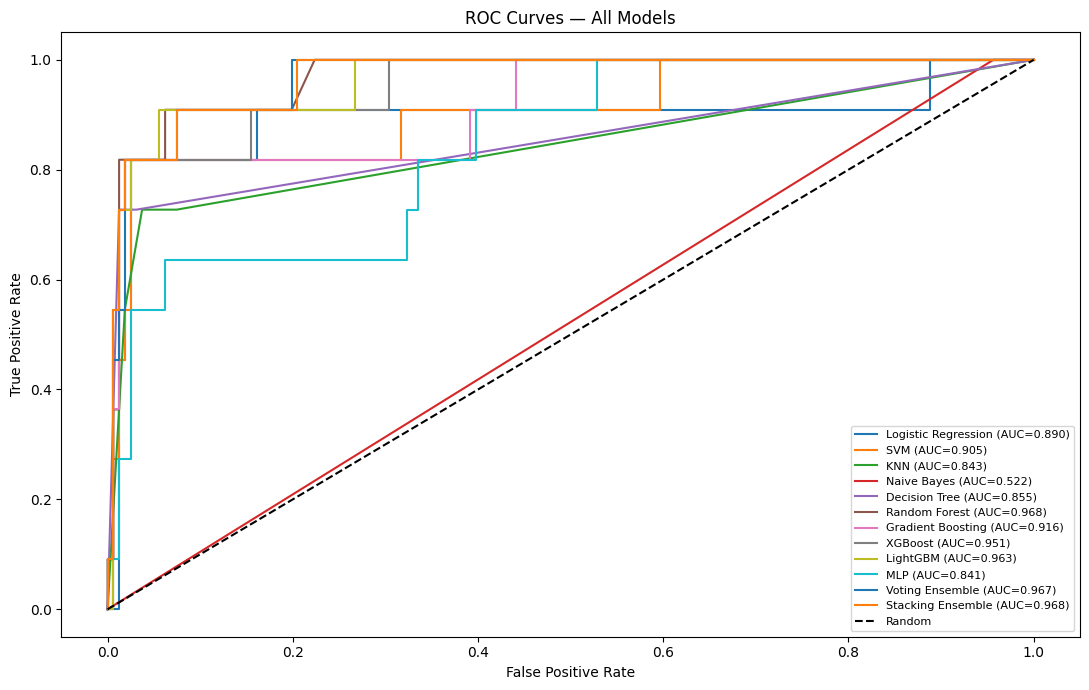

In [ ]:
# ── 9a: ROC Curves for all models ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

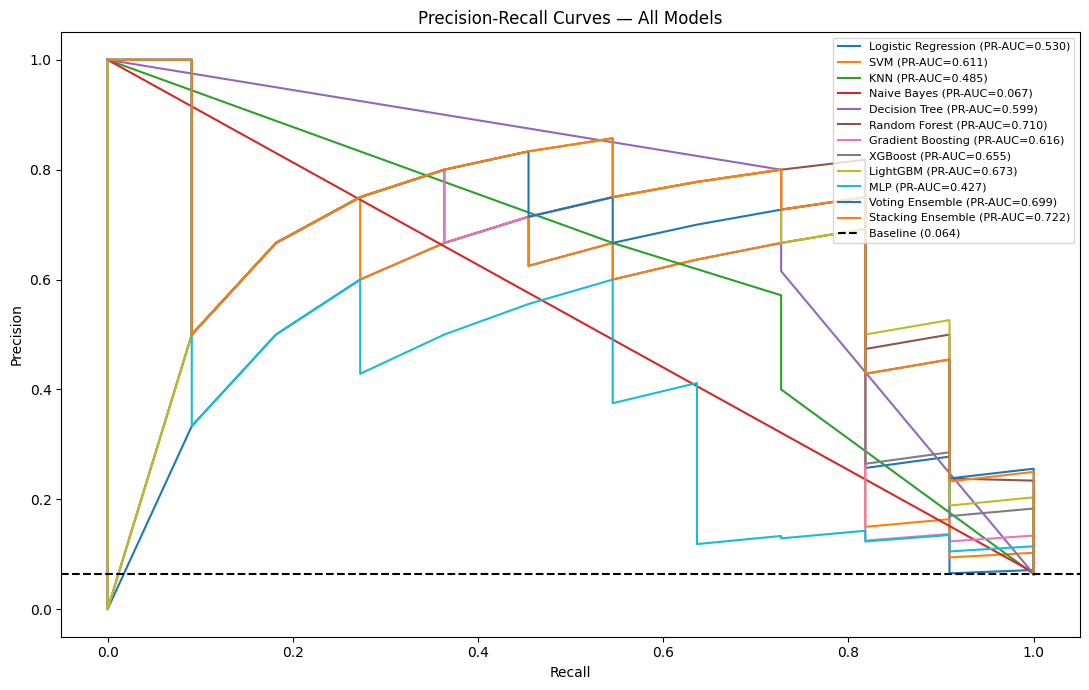

In [ ]:
# ── 9b: Precision-Recall Curves ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for name, r in results.items():
    precision, recall, _ = precision_recall_curve(y_test, r['y_proba'])
    ax.plot(recall, precision, label=f"{name} (PR-AUC={r['pr_auc']:.3f})")

baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

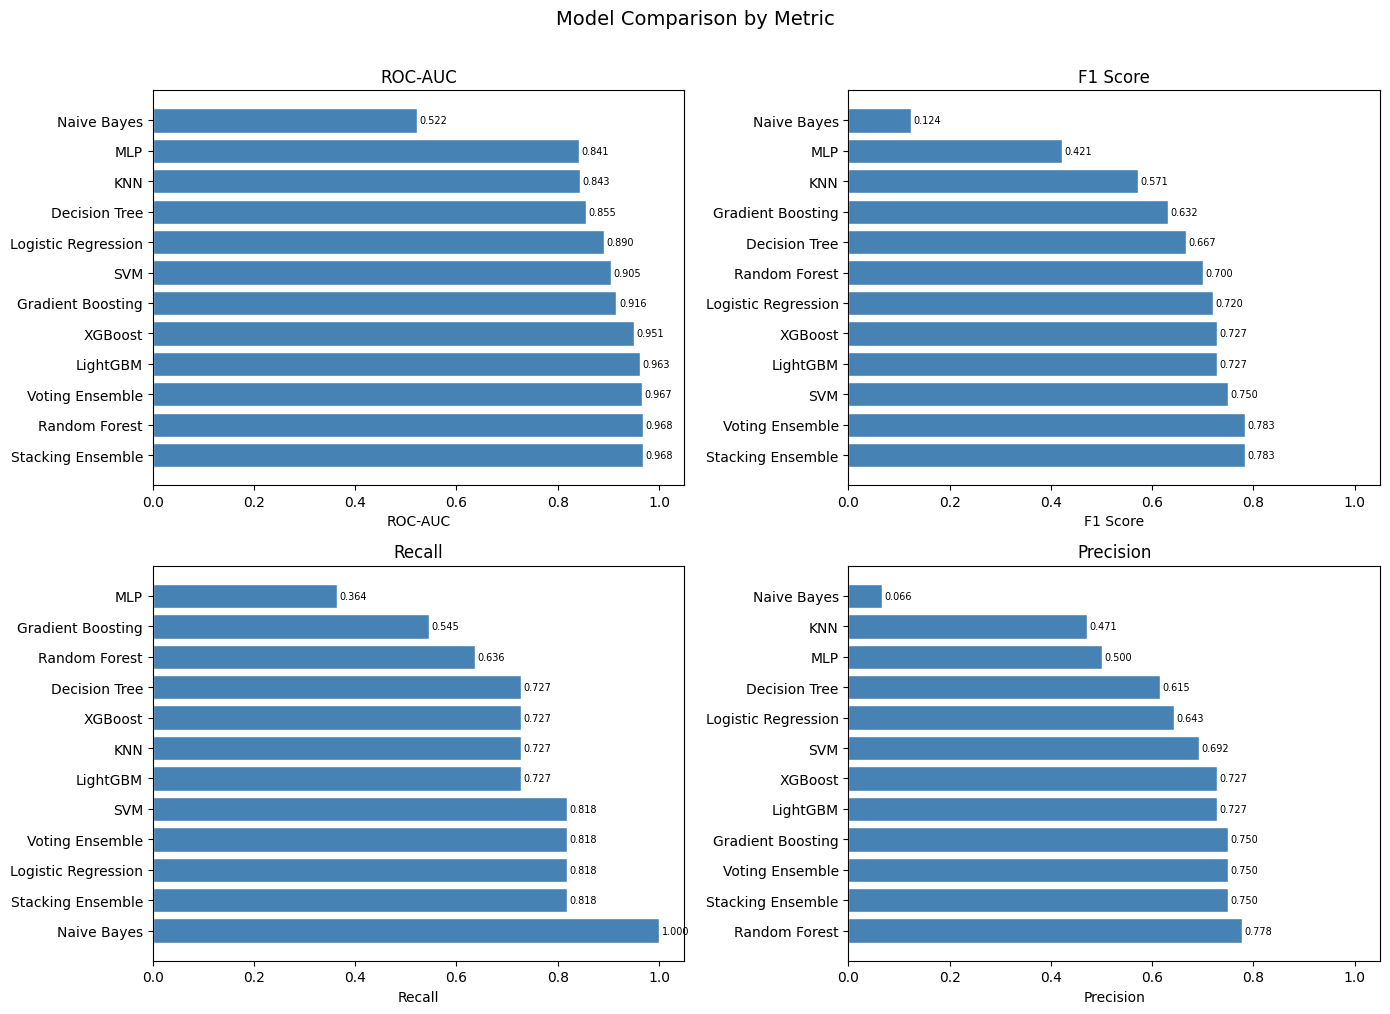

In [ ]:
# ── 9c: Metric bar chart ────────────────────────────────────────────────────────
metrics_to_plot = ['ROC-AUC', 'F1 Score', 'Recall', 'Precision']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    vals = comparison_df[metric].sort_values(ascending=False)
    bars = ax.barh(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(metric)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=7)

plt.suptitle('Model Comparison by Metric', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

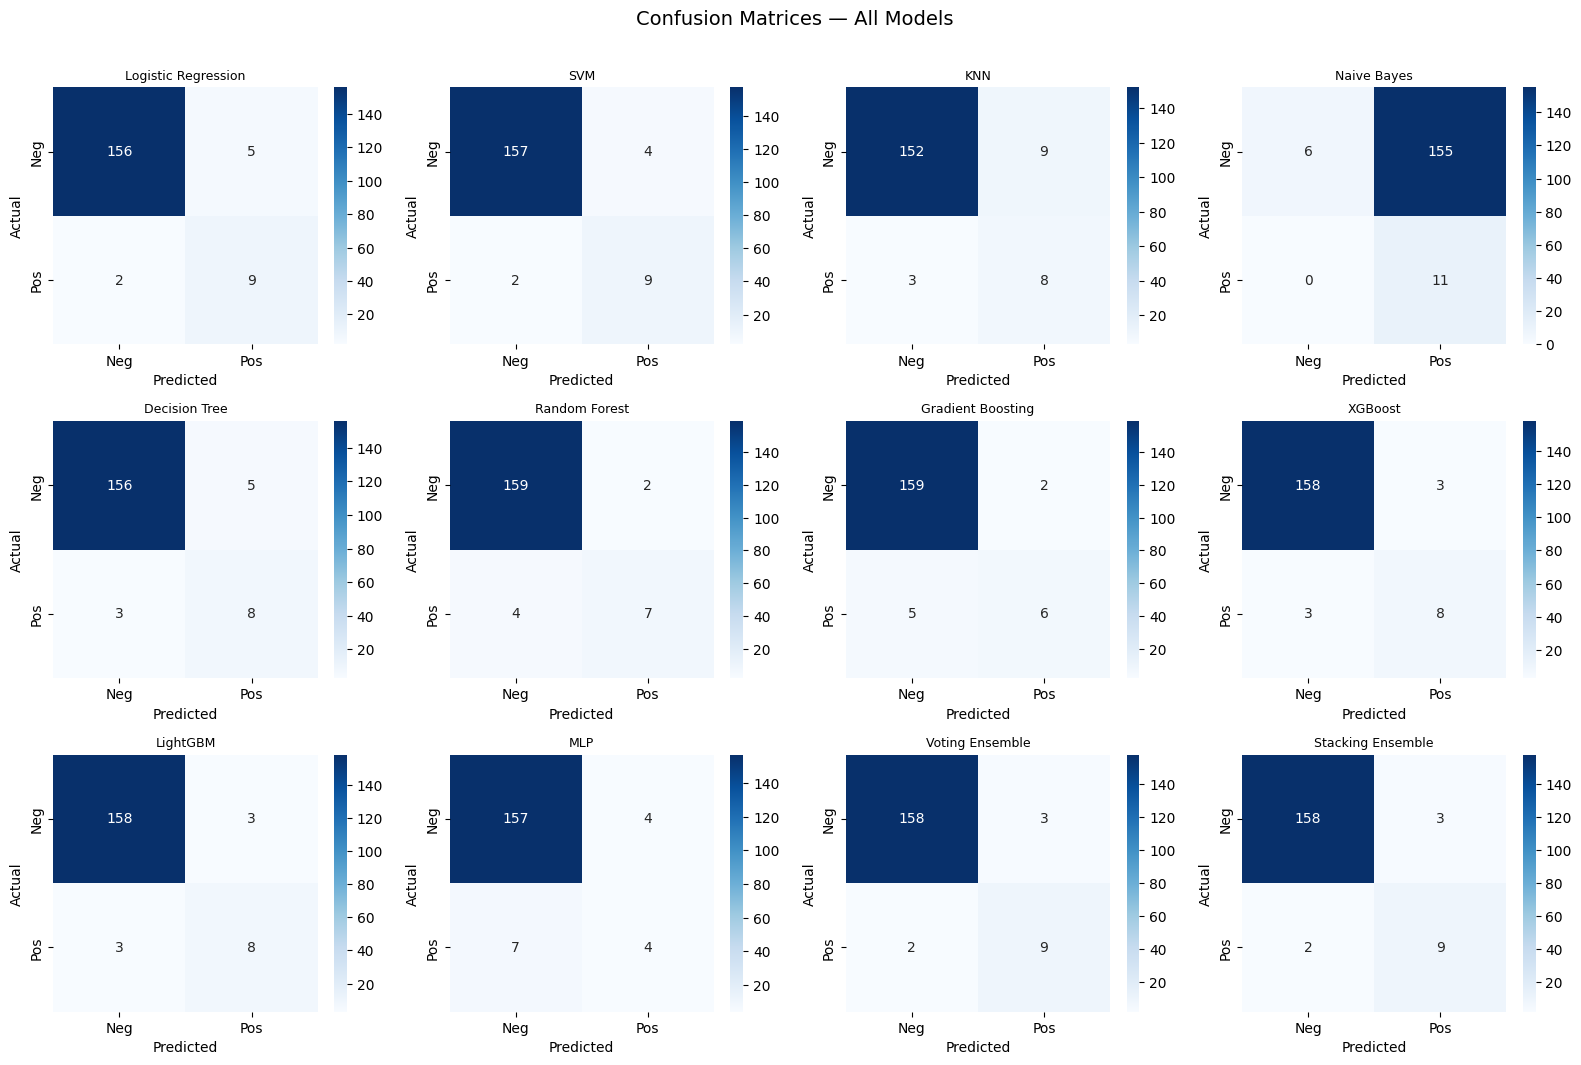

In [ ]:
# ── 9d: Confusion Matrices for all models ───────────────────────────────────────
n = len(results)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

##10. Stratified K-fold Cross Validation

In [ ]:
# Cross-validation on full dataset (imputed, scaled)
# Using ImbPipeline to apply SMOTE inside each fold correctly

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight,
                                         eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM':            LGBMClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight,
                                          random_state=42, verbosity=-1),
    'MLP':                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

X_scaled_full = scaler.fit_transform(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in cv_models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf', model)
    ])
    auc_scores = cross_val_score(pipe, X_scaled_full, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, X_scaled_full, y, cv=skf, scoring='f1',      n_jobs=-1)
    cv_results[name] = {'AUC mean': auc_scores.mean(), 'AUC std': auc_scores.std(),
                        'F1 mean':  f1_scores.mean(),  'F1 std':  f1_scores.std()}
    print(f'{name:25s}  AUC={auc_scores.mean():.4f}±{auc_scores.std():.4f}  F1={f1_scores.mean():.4f}±{f1_scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).T.round(4)
print('\nCross-Validation Summary:')
cv_df

Logistic Regression        AUC=0.9153±0.0506  F1=0.6546±0.0485
Random Forest              AUC=0.9399±0.0425  F1=0.6437±0.1318
XGBoost                    AUC=0.9361±0.0451  F1=0.6686±0.0994
LightGBM                   AUC=0.9430±0.0282  F1=0.6451±0.1424
MLP                        AUC=0.9069±0.0520  F1=0.5337±0.1261

Cross-Validation Summary:


,AUC mean,AUC std,F1 mean,F1 std
Logistic Regression,0.9153,0.0506,0.6546,0.0485
Random Forest,0.9399,0.0425,0.6437,0.1318
XGBoost,0.9361,0.0451,0.6686,0.0994
LightGBM,0.9430,0.0282,0.6451,0.1424
MLP,0.9069,0.0520,0.5337,0.1261


##11. Hyperparameter Tuning

In [ ]:
# Tune XGBoost — typically the top performer on tabular medical data
param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 5, 6],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.6, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.8, 1.0],
    'min_child_weight':[1, 3, 5],
    'gamma':           [0, 0.1, 0.3],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42, verbosity=0
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

print(f'Best CV AUC: {random_search.best_score_:.4f}')
print(f'Best params: {random_search.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC: 0.9978
Best params: {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [ ]:
# Evaluate tuned model
best_xgb = random_search.best_estimator_
y_pred_tuned  = best_xgb.predict(X_test_scaled)
y_proba_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

results['XGBoost (Tuned)'] = {
    'model':     best_xgb,
    'y_pred':    y_pred_tuned,
    'y_proba':   y_proba_tuned,
    'accuracy':  accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'recall':    recall_score(y_test, y_pred_tuned, zero_division=0),
    'f1':        f1_score(y_test, y_pred_tuned, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, y_proba_tuned),
    'pr_auc':    average_precision_score(y_test, y_proba_tuned),
}

r = results['XGBoost (Tuned)']
print(f"XGBoost (Tuned) — AUC={r['roc_auc']:.4f}  F1={r['f1']:.4f}  Recall={r['recall']:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))

XGBoost (Tuned) — AUC=0.9260  F1=0.7500  Recall=0.8182
              precision    recall  f1-score   support

    Negative       0.99      0.98      0.98       161
    Positive       0.69      0.82      0.75        11

    accuracy                           0.97       172
   macro avg       0.84      0.90      0.87       172
weighted avg       0.97      0.97      0.97       172



##12. Decision Threshold Tuning

In medical screening, **recall(senstivity)** is critical

In [ ]:
# Find optimal threshold for the best model using the F1-maximising approach
# Also show the high-recall threshold

best_model_name = comparison_df['ROC-AUC'].idxmax()
best_proba      = results[best_model_name]['y_proba']

precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)

# F1-optimal threshold
f1_scores_thr = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx      = f1_scores_thr.argmax()
best_thr      = thresholds[best_idx]

# High-recall threshold (recall ≥ 0.90)
recall_idx       = np.where(recalls[:-1] >= 0.90)[0]
high_recall_thr  = thresholds[recall_idx[-1]] if len(recall_idx) else best_thr

print(f'Best model: {best_model_name}')
print(f'F1-optimal threshold:    {best_thr:.3f}')
print(f'High-recall threshold:   {high_recall_thr:.3f}')

for label, thr in [('Default (0.5)', 0.5), (f'F1-optimal ({best_thr:.2f})', best_thr),
                   (f'High-recall ({high_recall_thr:.2f})', high_recall_thr)]:
    y_adj = (best_proba >= thr).astype(int)
    print(f'\n{label}:')
    print(f'  Precision={precision_score(y_test, y_adj, zero_division=0):.3f}  '
          f'Recall={recall_score(y_test, y_adj, zero_division=0):.3f}  '
          f'F1={f1_score(y_test, y_adj, zero_division=0):.3f}')

Best model: Stacking Ensemble
F1-optimal threshold:    0.510
High-recall threshold:   0.013

Default (0.5):
  Precision=0.750  Recall=0.818  F1=0.783

F1-optimal (0.51):
  Precision=0.750  Recall=0.818  F1=0.783

High-recall (0.01):
  Precision=0.455  Recall=0.909  F1=0.606


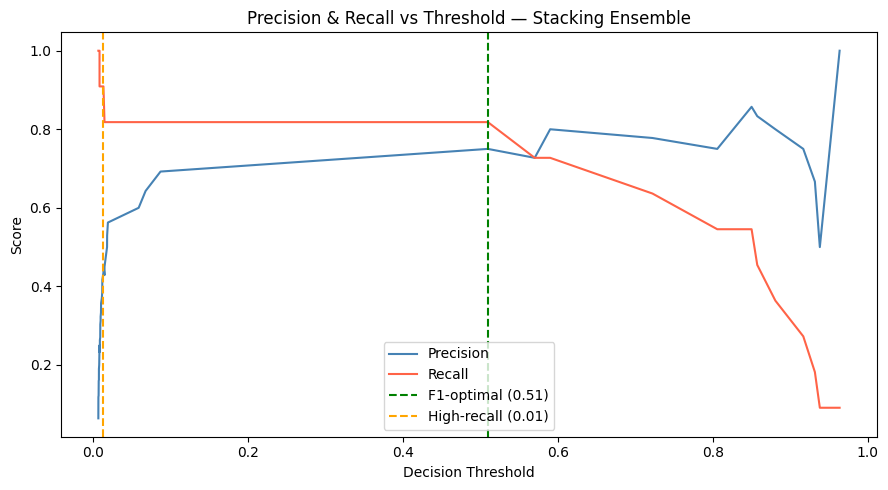

In [ ]:
# Plot precision / recall vs threshold
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='tomato')
ax.axvline(x=best_thr,       color='green',  linestyle='--', label=f'F1-optimal ({best_thr:.2f})')
ax.axvline(x=high_recall_thr, color='orange', linestyle='--', label=f'High-recall ({high_recall_thr:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision & Recall vs Threshold — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

##13. Feature Importance & SHAP Interpretability

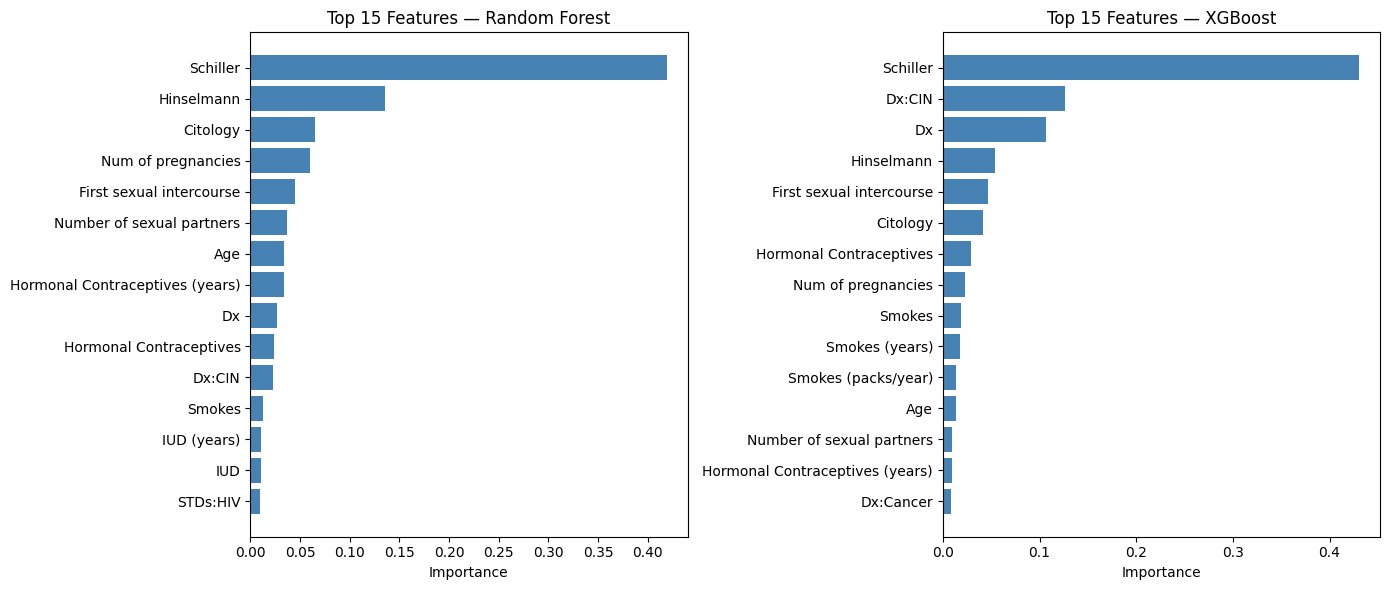

In [ ]:
# ── 13a: Feature Importance from Random Forest & XGBoost ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
feature_names = list(X.columns)

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model_obj = results[model_name]['model']
    importances = model_obj.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(15)
    ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='steelblue')
    ax.set_title(f'Top 15 Features — {model_name}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

SHAP Summary Plot (bar):


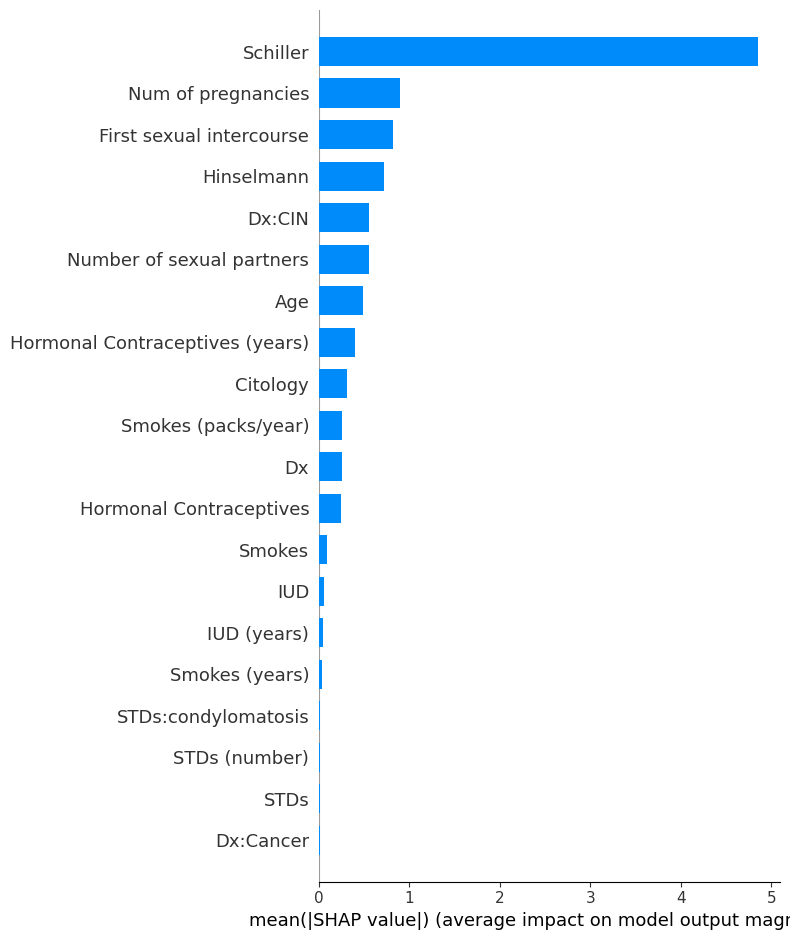


SHAP Summary Plot (beeswarm):


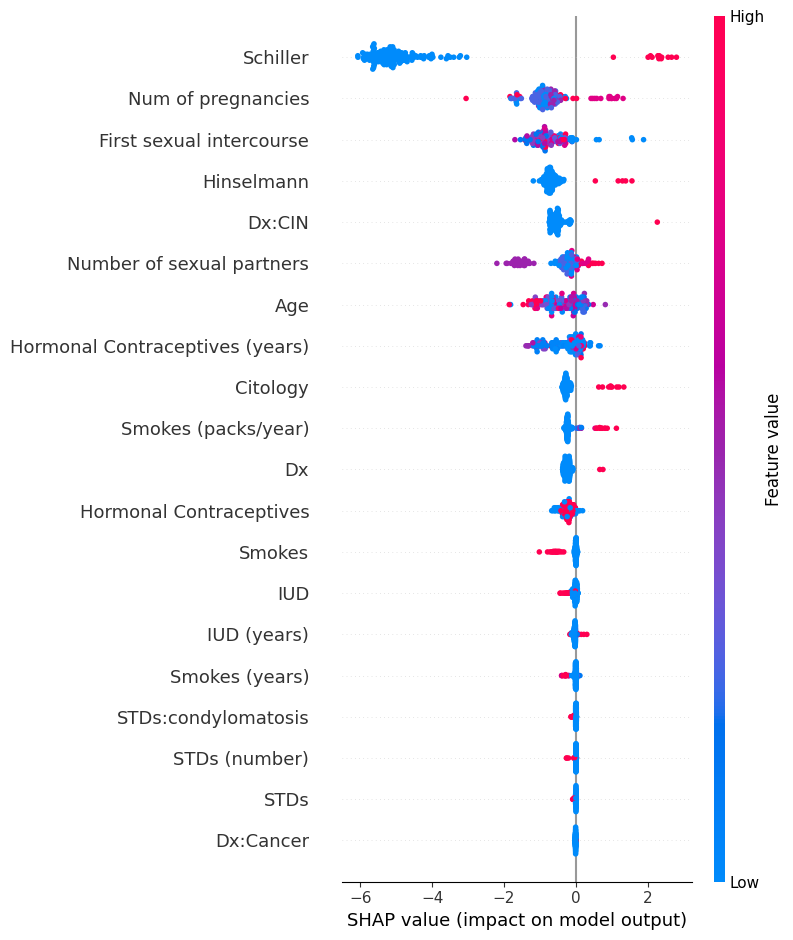

In [ ]:
# ── 13b: SHAP Values for XGBoost (best tree model) ───────────────────────────
xgb_model = results['XGBoost']['model']

# Use a sample for speed (200 rows)
shap_sample = X_test_scaled[:200]
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP Summary Plot (bar):')
shap.summary_plot(
    shap_values, shap_sample,
    feature_names=feature_names,
    plot_type='bar', show=True
)

print('\nSHAP Summary Plot (beeswarm):')
shap.summary_plot(
    shap_values, shap_sample,
    feature_names=feature_names,
    show=True
)

##14. Final Model Comparison

In [ ]:
final_df = pd.DataFrame({
    name: {
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
        'F1 Score':  round(r['f1'],        4),
        'ROC-AUC':   round(r['roc_auc'],   4),
        'PR-AUC':    round(r['pr_auc'],    4),
    }
    for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print('Final Model Comparison (sorted by ROC-AUC):')
final_df

Final Model Comparison (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Random Forest,0.9651,0.7778,0.6364,0.7000,0.9678,0.7101
Stacking Ensemble,0.9709,0.7500,0.8182,0.7826,0.9678,0.7218
Voting Ensemble,0.9709,0.7500,0.8182,0.7826,0.9667,0.6989
LightGBM,0.9651,0.7273,0.7273,0.7273,0.9627,0.6734
XGBoost,0.9651,0.7273,0.7273,0.7273,0.9509,0.6549
XGBoost (Tuned),0.9651,0.6923,0.8182,0.7500,0.9260,0.6799
Gradient Boosting,0.9593,0.7500,0.5455,0.6316,0.9159,0.6164
SVM,0.9651,0.6923,0.8182,0.7500,0.9051,0.6115
Logistic Regression,0.9593,0.6429,0.8182,0.7200,0.8905,0.5296
Decision Tree,0.9535,0.6154,0.7273,0.6667,0.8549,0.5993


In [ ]:
# ── Identify best model ────────────────────────────────────────────────────────
best_name   = final_df['ROC-AUC'].idxmax()
best_result = results[best_name]

print(f'\n>>> Best Model: {best_name} <<<')
print(f'  ROC-AUC:   {best_result["roc_auc"]:.4f}')
print(f'  F1 Score:  {best_result["f1"]:.4f}')
print(f'  Recall:    {best_result["recall"]:.4f}')
print(f'  Precision: {best_result["precision"]:.4f}')
print()
print(classification_report(y_test, best_result['y_pred'], target_names=['Negative', 'Positive']))


>>> Best Model: Random Forest <<<
  ROC-AUC:   0.9678
  F1 Score:  0.7000
  Recall:    0.6364
  Precision: 0.7778

              precision    recall  f1-score   support

    Negative       0.98      0.99      0.98       161
    Positive       0.78      0.64      0.70        11

    accuracy                           0.97       172
   macro avg       0.88      0.81      0.84       172
weighted avg       0.96      0.97      0.96       172



##15. Save all Models

In [ ]:
save_dir = '/content/drive/MyDrive/cervical-cancer-ml/models/'

# Save scaler
joblib.dump(scaler, save_dir + 'scaler.pkl')
print('Saved: scaler.pkl')

# Save all individual models
model_files = {
    'Logistic Regression': 'lr_model.pkl',
    'SVM':                 'svm_model.pkl',
    'KNN':                 'knn_model.pkl',
    'Naive Bayes':         'nb_model.pkl',
    'Decision Tree':       'dt_model.pkl',
    'Random Forest':       'rf_model.pkl',
    'Gradient Boosting':   'gb_model.pkl',
    'XGBoost':             'xgb_model.pkl',
    'LightGBM':            'lgbm_model.pkl',
    'MLP':                 'mlp_model.pkl',
    'Voting Ensemble':     'voting_model.pkl',
    'Stacking Ensemble':   'stacking_model.pkl',
    'XGBoost (Tuned)':     'xgb_tuned_model.pkl',
}

for name, filename in model_files.items():
    if name in results:
        joblib.dump(results[name]['model'], save_dir + filename)
        print(f'Saved: {filename}')

print('\nAll models saved!')

Saved: scaler.pkl
Saved: lr_model.pkl
Saved: svm_model.pkl
Saved: knn_model.pkl
Saved: nb_model.pkl
Saved: dt_model.pkl
Saved: rf_model.pkl
Saved: gb_model.pkl
Saved: xgb_model.pkl
Saved: lgbm_model.pkl
Saved: mlp_model.pkl
Saved: voting_model.pkl
Saved: stacking_model.pkl
Saved: xgb_tuned_model.pkl

All models saved!


In [ ]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         